# 03 — Exploratory Data Analysis
Covers: population trajectories, energy per capita by phase, correlation heatmaps (raw + de-meaned), Simpson's Paradox fix, year-over-year change tests, 10-year correlations, electricity demand, carbon intensity vs renewables, policy chart.
**Input:** `actuals_final.csv`, `energy_data.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

actuals_final = pd.read_csv("actuals_final.csv")
energy_df = pd.read_csv("energy_data.csv")

COUNTRIES = {
    "JPN": "Japan", "DEU": "Germany", "CHN": "China",
    "IND": "India", "IDN": "Indonesia", "USA": "United States", "BRA": "Brazil",
}
EXCLUDED_COUNTRIES = ["NGA"]
countries_plot = [c for c in COUNTRIES.keys() if c not in EXCLUDED_COUNTRIES]

print(f"actuals_final: {actuals_final.shape}")

actuals_final: (520, 20)


## 1. Population Trajectory

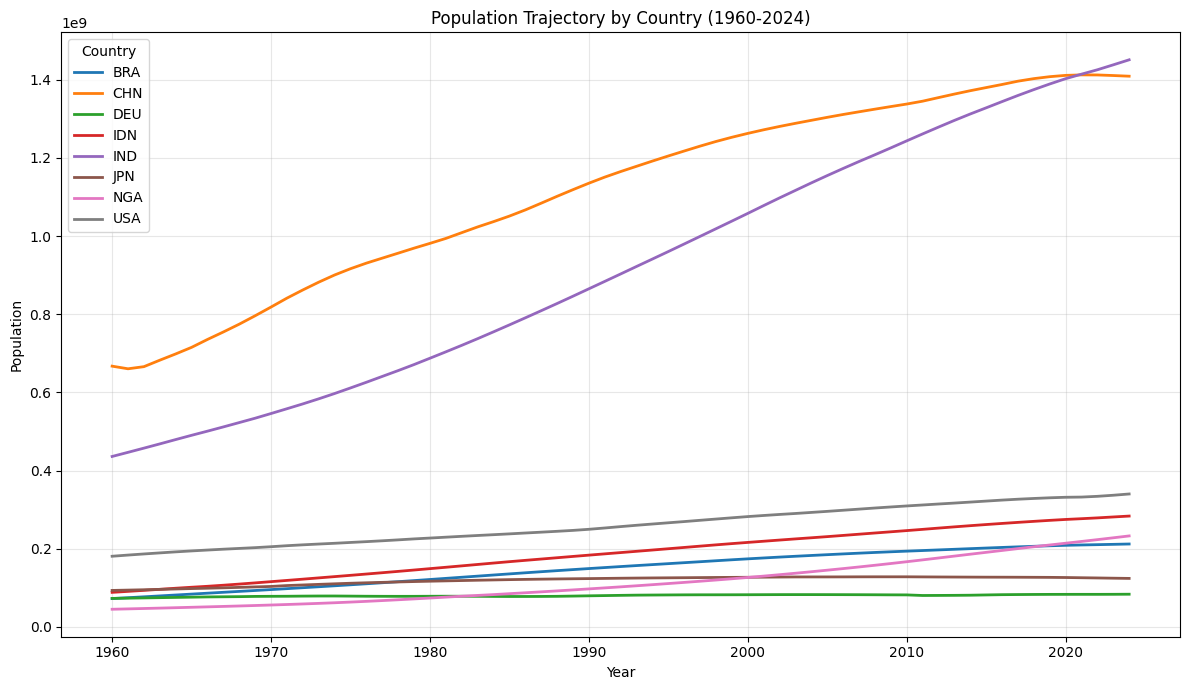

In [2]:
fig, ax = plt.subplots(figsize=(12, 7))
for code in actuals_final["country_code"].unique():
    subset = actuals_final[actuals_final["country_code"] == code]
    ax.plot(subset["year"], subset["population_total"], label=code, linewidth=2)
ax.set_title("Population Trajectory by Country (1960-2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Population")
ax.legend(title="Country", loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("eda_population_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Energy per Capita by Demographic Phase

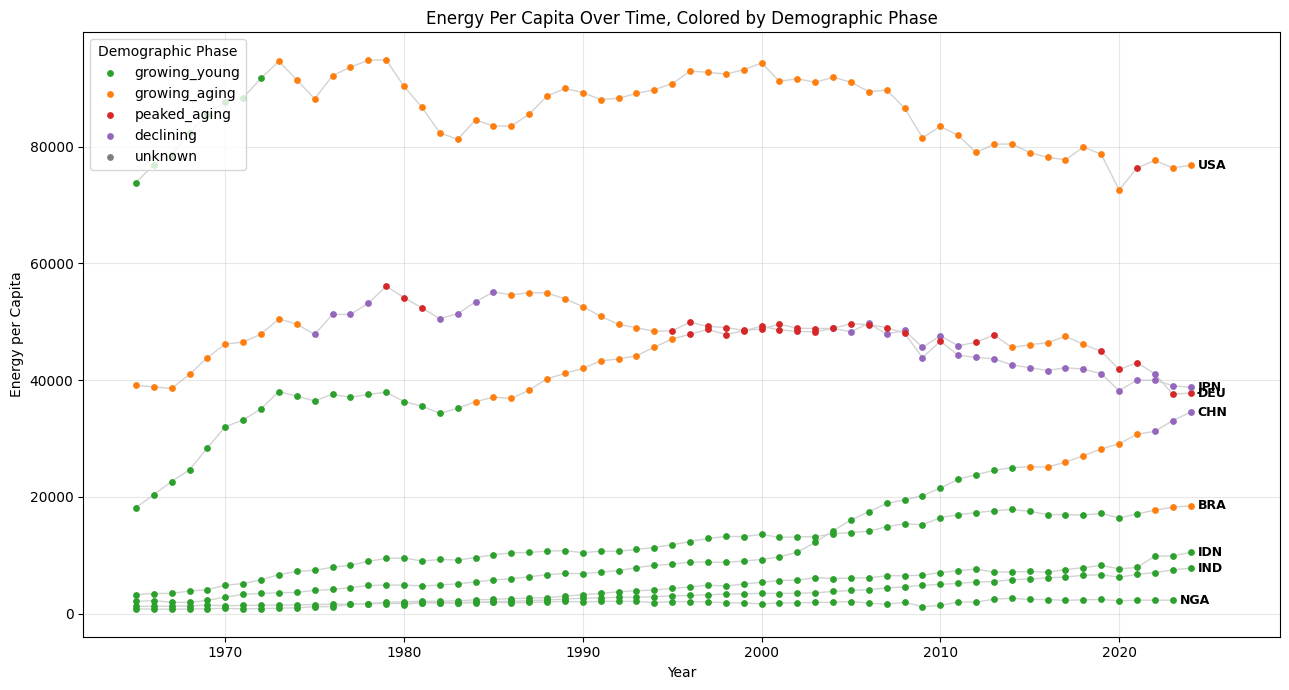

In [3]:
phase_colors = {
    "growing_young": "tab:green", "growing_aging": "tab:orange",
    "peaked_aging": "tab:red", "declining": "tab:purple", "unknown": "tab:gray",
}
fig, ax = plt.subplots(figsize=(13, 7))
for code in actuals_final["country_code"].unique():
    subset = actuals_final[actuals_final["country_code"] == code].sort_values("year")
    ax.plot(subset["year"], subset["energy_per_capita"], color="lightgray", linewidth=1, zorder=1)
    for phase, color in phase_colors.items():
        phase_subset = subset[subset["demographic_phase"] == phase]
        ax.scatter(phase_subset["year"], phase_subset["energy_per_capita"],
                   color=color, label=phase, s=15, zorder=2)
    last_row = subset.dropna(subset=["energy_per_capita"]).iloc[-1]
    ax.annotate(code, xy=(last_row["year"], last_row["energy_per_capita"]),
                xytext=(5, 0), textcoords="offset points", fontsize=9, fontweight="bold", va="center")
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), title="Demographic Phase", loc="upper left")
ax.set_title("Energy Per Capita Over Time, Colored by Demographic Phase")
ax.set_xlabel("Year")
ax.set_ylabel("Energy per Capita")
ax.set_xlim(right=actuals_final["year"].max() + 5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("eda_energy_by_phase.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Within-Country Correlation Heatmap (raw levels)

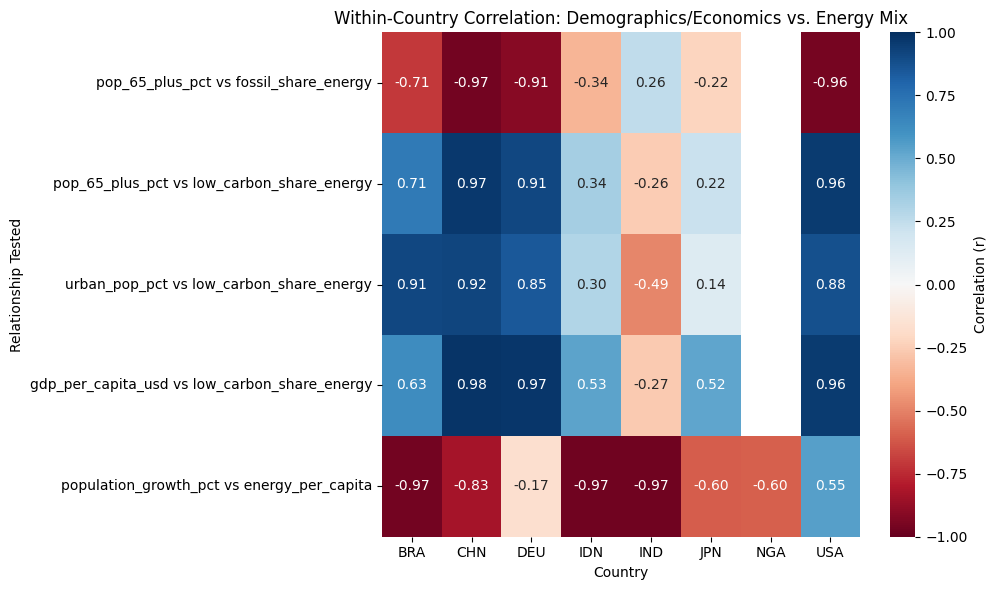

In [4]:
pairs = [
    ("pop_65_plus_pct", "fossil_share_energy"),
    ("pop_65_plus_pct", "low_carbon_share_energy"),
    ("urban_pop_pct", "low_carbon_share_energy"),
    ("gdp_per_capita_usd", "low_carbon_share_energy"),
    ("population_growth_pct", "energy_per_capita"),
]
countries = actuals_final["country_code"].unique()
corr_matrix = pd.DataFrame(index=countries, columns=[f"{x} vs {y}" for x, y in pairs])
for code in countries:
    subset = actuals_final[actuals_final["country_code"] == code]
    for x_col, y_col in pairs:
        clean = subset[[x_col, y_col]].dropna()
        if len(clean) >= 5:
            corr_matrix.loc[code, f"{x_col} vs {y_col}"] = clean[x_col].corr(clean[y_col])
corr_matrix = corr_matrix.astype(float).T
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu", center=0, vmin=-1, vmax=1,
            ax=ax, cbar_kws={"label": "Correlation (r)"})
ax.set_title("Within-Country Correlation: Demographics/Economics vs. Energy Mix")
ax.set_xlabel("Country")
ax.set_ylabel("Relationship Tested")
plt.tight_layout()
plt.savefig("eda_within_country_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Simpson's Paradox Fix — De-meaned By-Phase Heatmap

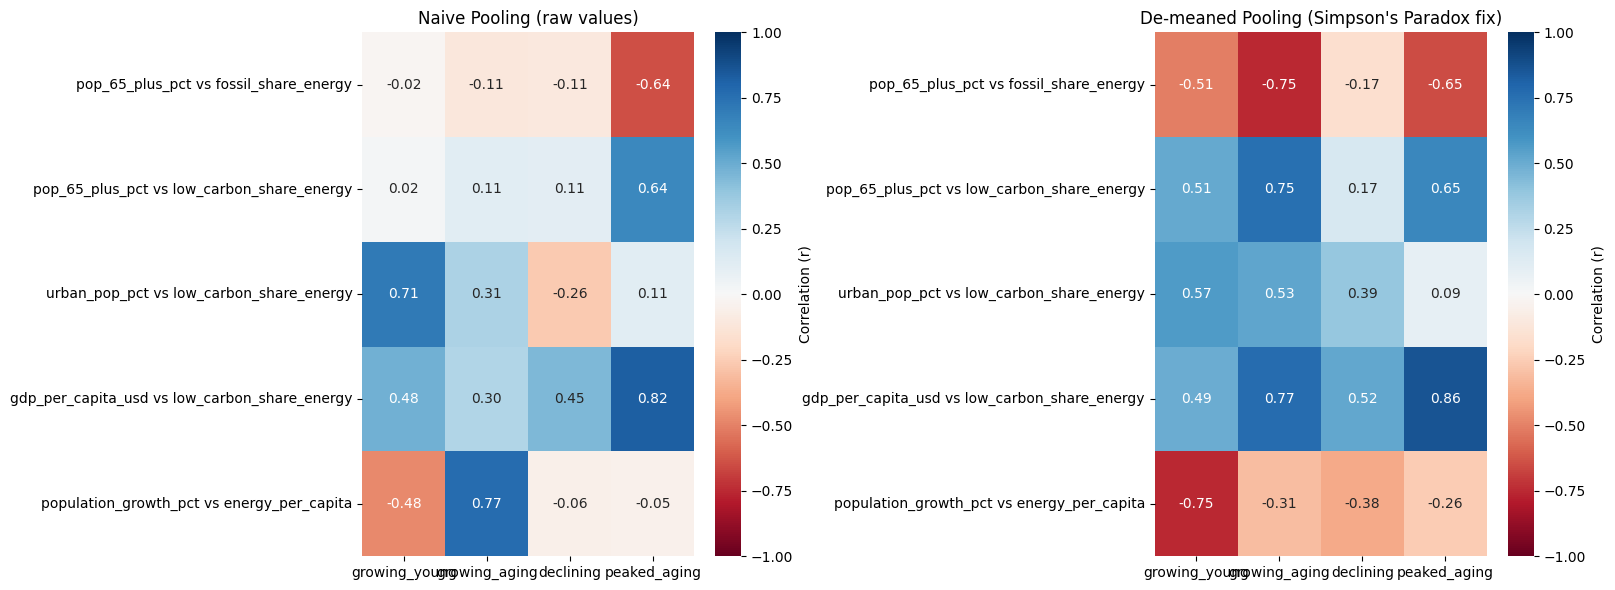

In [5]:
cols_to_demean = ["urban_pop_pct", "low_carbon_share_energy", "pop_65_plus_pct",
                  "fossil_share_energy", "gdp_per_capita_usd", "population_growth_pct", "energy_per_capita"]
actuals_demeaned = actuals_final.copy()
for col in cols_to_demean:
    actuals_demeaned[col] = actuals_demeaned.groupby("country_code")[col].transform(lambda x: x - x.mean())

phases = [p for p in actuals_final["demographic_phase"].unique() if p != "unknown"]
corr_naive = pd.DataFrame(index=phases, columns=[f"{x} vs {y}" for x, y in pairs])
corr_demeaned = pd.DataFrame(index=phases, columns=[f"{x} vs {y}" for x, y in pairs])

for phase in phases:
    for df_src, df_out in [(actuals_final, corr_naive), (actuals_demeaned, corr_demeaned)]:
        subset = df_src[df_src["demographic_phase"] == phase]
        for x_col, y_col in pairs:
            clean = subset[[x_col, y_col]].dropna()
            if len(clean) >= 5:
                df_out.loc[phase, f"{x_col} vs {y_col}"] = clean[x_col].corr(clean[y_col])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_naive.astype(float).T, annot=True, fmt=".2f", cmap="RdBu", center=0,
            vmin=-1, vmax=1, ax=axes[0], cbar_kws={"label": "Correlation (r)"})
axes[0].set_title("Naive Pooling (raw values)")
sns.heatmap(corr_demeaned.astype(float).T, annot=True, fmt=".2f", cmap="RdBu", center=0,
            vmin=-1, vmax=1, ax=axes[1], cbar_kws={"label": "Correlation (r)"})
axes[1].set_title("De-meaned Pooling (Simpson's Paradox fix)")
plt.tight_layout()
plt.savefig("eda_simpsons_paradox.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Year-over-Year Change Correlation Tests (trend confounding check)

In [6]:
diff_df = actuals_final.sort_values(["country_code", "year"]).copy()
for col in ["pop_65_plus_pct", "low_carbon_share_energy", "renewables_share_energy",
            "fossil_share_energy", "energy_per_capita", "population_growth_pct"]:
    diff_df[f"{col}_chg"] = diff_df.groupby("country_code")[col].diff()

yoy_pairs = [
    ("pop_65_plus_pct", "low_carbon_share_energy", "% 65+ vs low-carbon share"),
    ("pop_65_plus_pct", "renewables_share_energy", "% 65+ vs renewables share"),
    ("pop_65_plus_pct", "fossil_share_energy", "% 65+ vs fossil share"),
]
for x_col, y_col, label in yoy_pairs:
    print(f"\nYear-over-year: {label}")
    for code in diff_df["country_code"].unique():
        subset = diff_df[diff_df["country_code"] == code].dropna(
            subset=[f"{x_col}_chg", f"{y_col}_chg"])
        if len(subset) >= 5:
            r = subset[f"{x_col}_chg"].corr(subset[f"{y_col}_chg"])
            print(f"  {code}: r={r:.2f}, n={len(subset)}")


Year-over-year: % 65+ vs low-carbon share
  BRA: r=0.05, n=59
  CHN: r=0.55, n=59
  DEU: r=-0.09, n=59
  IDN: r=0.07, n=59
  IND: r=0.15, n=59
  JPN: r=-0.24, n=59
  USA: r=0.24, n=59

Year-over-year: % 65+ vs renewables share
  BRA: r=0.06, n=59
  CHN: r=0.49, n=59
  DEU: r=0.21, n=59
  IDN: r=0.07, n=59
  IND: r=0.16, n=59
  JPN: r=0.16, n=59
  USA: r=0.39, n=59

Year-over-year: % 65+ vs fossil share
  BRA: r=-0.05, n=59
  CHN: r=-0.55, n=59
  DEU: r=0.09, n=59
  IDN: r=-0.07, n=59
  IND: r=-0.15, n=59
  JPN: r=0.24, n=59
  USA: r=-0.24, n=59


## 6. 10-Year Change Correlation Table

In [8]:
model_df = pd.read_csv("model_df.csv")
diff_10 = model_df.sort_values(["country_code", "year"]).copy()
cols_to_diff = ["population_total", "population_growth_pct", "pop_65_plus_pct",
                "pop_working_age_pct", "urban_pop_pct", "gdp_per_capita_usd",
                "primary_energy_consumption", "energy_per_capita"]
for col in cols_to_diff:
    diff_10[f"{col}_10yr"] = diff_10.groupby("country_code")[col].diff(10)

ten_yr_pairs = [
    ("population_total_10yr", "primary_energy_consumption_10yr"),
    ("population_total_10yr", "energy_per_capita_10yr"),
    ("pop_65_plus_pct_10yr", "energy_per_capita_10yr"),
    ("pop_working_age_pct_10yr", "energy_per_capita_10yr"),
    ("gdp_per_capita_usd_10yr", "energy_per_capita_10yr"),
    ("urban_pop_pct_10yr", "energy_per_capita_10yr"),
]
results = []
for x_col, y_col in ten_yr_pairs:
    row = {"x": x_col.replace("_10yr",""), "y": y_col.replace("_10yr","")}
    for code in diff_10["country_code"].unique():
        subset = diff_10[diff_10["country_code"] == code].dropna(subset=[x_col, y_col])
        if len(subset) >= 5:
            row[code] = round(subset[x_col].corr(subset[y_col]), 2)
    results.append(row)
print(pd.DataFrame(results).set_index(["x", "y"]))

                                                 BRA   CHN   DEU   IDN   IND  \
x                   y                                                          
population_total    primary_energy_consumption -0.07 -0.88 -0.17 -0.69  0.18   
                    energy_per_capita           0.23 -0.84 -0.34 -0.30  0.22   
pop_65_plus_pct     energy_per_capita          -0.43  0.55 -0.01  0.66  0.72   
pop_working_age_pct energy_per_capita           0.50 -0.37  0.51  0.42  0.84   
gdp_per_capita_usd  energy_per_capita           0.57  0.79 -0.28 -0.00  0.91   
urban_pop_pct       energy_per_capita           0.52  0.78 -0.01  0.58  0.19   

                                                 JPN   NGA   USA  
x                   y                                             
population_total    primary_energy_consumption  0.74  0.69  0.25  
                    energy_per_capita           0.68  0.43  0.12  
pop_65_plus_pct     energy_per_capita          -0.56  0.37 -0.37  
pop_working_age_pct ener

## 7. Carbon Intensity vs Renewables (all countries)

In [9]:
# Pull GHG columns back from energy_df
ghg_data = energy_df[["iso_code", "year", "greenhouse_gas_emissions", "carbon_intensity_elec"]].rename(
    columns={"iso_code": "country_code"})
actuals_final = actuals_final.merge(ghg_data, on=["country_code", "year"], how="left")

# Compute correlations
candidates = ["gdp_per_capita_usd", "carbon_intensity_elec", "urban_pop_pct",
              "energy_per_gdp", "greenhouse_gas_emissions", "pop_working_age_pct", "pop_65_plus_pct"]
diff_df2 = actuals_final.sort_values(["country_code", "year"]).copy()
for col in candidates + ["renewables_share_energy"]:
    diff_df2[f"{col}_chg"] = diff_df2.groupby("country_code")[col].diff()

corr_results = []
for x_col in candidates:
    row = {"feature": x_col}
    for code in countries_plot:
        subset = diff_df2[diff_df2["country_code"] == code].dropna(
            subset=[f"{x_col}_chg", "renewables_share_energy_chg"])
        if len(subset) >= 5:
            row[code] = round(subset[f"{x_col}_chg"].corr(subset["renewables_share_energy_chg"]), 2)
    corr_results.append(row)

corr_df = pd.DataFrame(corr_results).set_index("feature")
print("Year-over-year correlation vs renewables share change:")
print(corr_df)

Year-over-year correlation vs renewables share change:
                           JPN   DEU   CHN   IND   IDN   USA   BRA
feature                                                           
gdp_per_capita_usd       -0.15 -0.05  0.35  0.02 -0.08  0.04 -0.17
carbon_intensity_elec    -0.33 -0.45 -0.90 -0.96 -0.49 -0.65 -0.87
urban_pop_pct            -0.22  0.11  0.09  0.21  0.02 -0.29  0.10
energy_per_gdp           -0.35 -0.20 -0.45 -0.19  0.05 -0.04  0.17
greenhouse_gas_emissions -0.47 -0.57 -0.46 -0.27 -0.21 -0.54 -0.82
pop_working_age_pct      -0.24 -0.26 -0.31  0.06 -0.06 -0.30 -0.27
pop_65_plus_pct           0.16  0.21  0.49  0.16  0.07  0.39  0.06


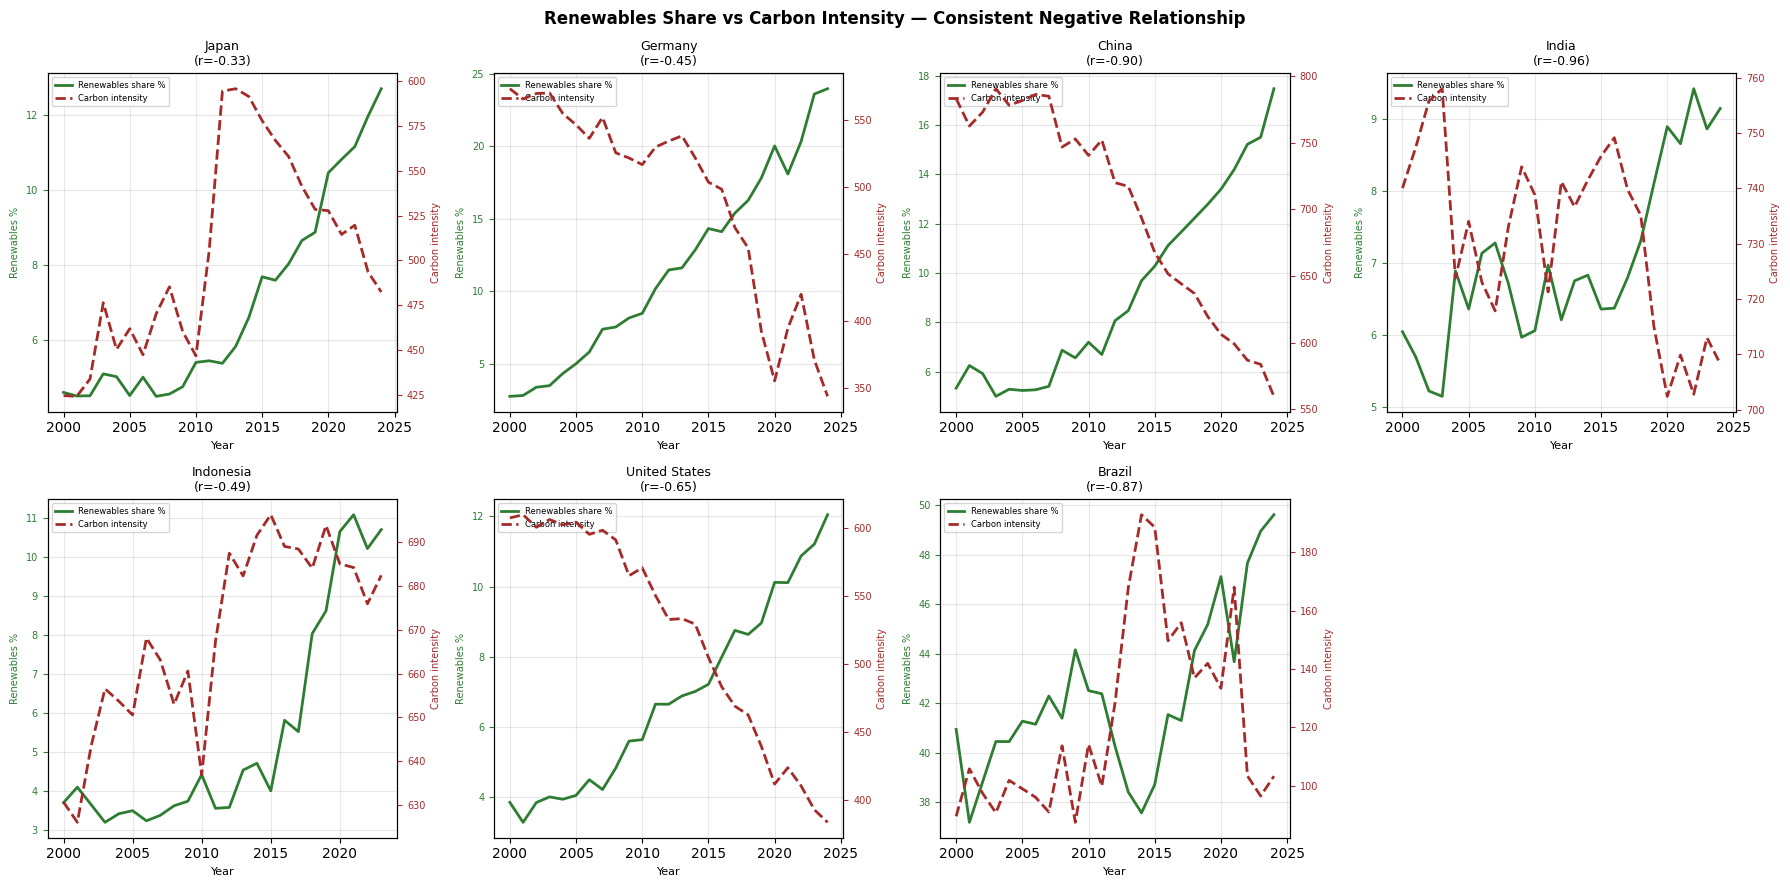

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for ax, code in zip(axes, countries_plot):
    country_data = actuals_final[actuals_final["country_code"] == code].dropna(
        subset=["carbon_intensity_elec", "renewables_share_energy"]).sort_values("year")
    ax2 = ax.twinx()
    line1, = ax.plot(country_data["year"], country_data["renewables_share_energy"],
                     color="#2e7d32", linewidth=2, label="Renewables share %")
    line2, = ax2.plot(country_data["year"], country_data["carbon_intensity_elec"],
                      color="brown", linewidth=2, linestyle="--", label="Carbon intensity")
    ax.set_title(f"{COUNTRIES[code]}\n(r={corr_df.loc['carbon_intensity_elec', code]:.2f})", fontsize=9)
    ax.set_xlabel("Year", fontsize=8)
    ax.set_ylabel("Renewables %", color="#2e7d32", fontsize=7)
    ax2.set_ylabel("Carbon intensity", color="brown", fontsize=7)
    ax.tick_params(axis="y", colors="#2e7d32", labelsize=7)
    ax2.tick_params(axis="y", colors="brown", labelsize=7)
    ax.grid(alpha=0.3)
    ax.legend([line1, line2], [line1.get_label(), line2.get_label()], fontsize=6, loc="upper left")
axes[-1].set_visible(False)
fig.suptitle("Renewables Share vs Carbon Intensity — Consistent Negative Relationship",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("renewables_vs_carbon_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Policy-Annotated Energy Mix Chart

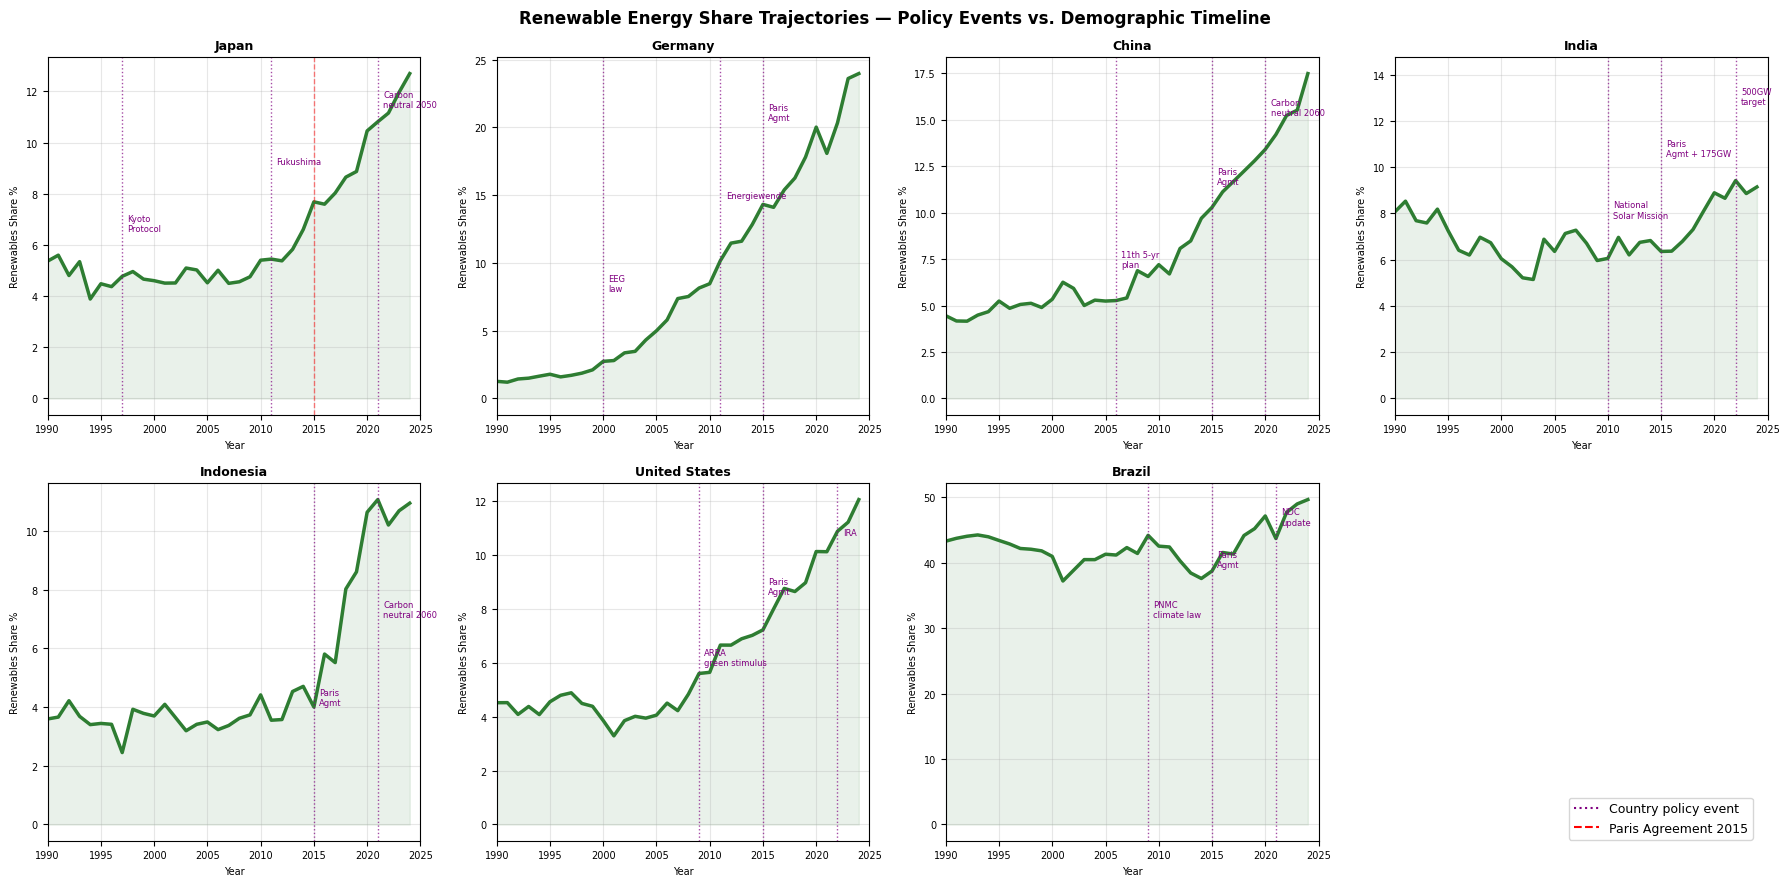

EDA complete — all charts saved.


In [11]:
from matplotlib.lines import Line2D

policy_events = {
    "JPN": [(1997, "Kyoto\nProtocol"), (2011, "Fukushima"), (2021, "Carbon\nneutral 2050")],
    "DEU": [(2000, "EEG\nlaw"), (2011, "Energiewende"), (2015, "Paris\nAgmt")],
    "CHN": [(2006, "11th 5-yr\nplan"), (2015, "Paris\nAgmt"), (2020, "Carbon\nneutral 2060")],
    "IND": [(2010, "National\nSolar Mission"), (2015, "Paris\nAgmt + 175GW"), (2022, "500GW\ntarget")],
    "IDN": [(2015, "Paris\nAgmt"), (2021, "Carbon\nneutral 2060")],
    "USA": [(2009, "ARRA\ngreen stimulus"), (2015, "Paris\nAgmt"), (2022, "IRA")],
    "BRA": [(2009, "PNMC\nclimate law"), (2015, "Paris\nAgmt"), (2021, "NDC\nupdate")],
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for ax, code in zip(axes, countries_plot):
    country_data = actuals_final[actuals_final["country_code"] == code].dropna(
        subset=["renewables_share_energy"]).sort_values("year")
    ax.plot(country_data["year"], country_data["renewables_share_energy"],
            color="#2e7d32", linewidth=2.5)
    ax.fill_between(country_data["year"], country_data["renewables_share_energy"],
                    alpha=0.1, color="#2e7d32")
    y_max = country_data["renewables_share_energy"].max()
    y_min = country_data["renewables_share_energy"].min()
    y_range = y_max - y_min
    heights = [y_min + y_range * h for h in [0.3, 0.6, 0.85]]
    for (year, label), height in zip(policy_events.get(code, []), heights):
        ax.axvline(x=year, color="purple", linestyle=":", linewidth=1, alpha=0.7)
        ax.annotate(label, xy=(year, height), xytext=(year + 0.5, height), fontsize=6, color="purple")
    if 2015 not in [e[0] for e in policy_events.get(code, [])]:
        ax.axvline(x=2015, color="red", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_title(f"{COUNTRIES[code]}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Year", fontsize=7)
    ax.set_ylabel("Renewables Share %", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)
    ax.set_xlim(1990, 2025)
axes[-1].set_visible(False)
legend_elements = [
    Line2D([0], [0], color="purple", linestyle=":", linewidth=1.5, label="Country policy event"),
    Line2D([0], [0], color="red", linestyle="--", linewidth=1.5, label="Paris Agreement 2015"),
]
fig.legend(handles=legend_elements, loc="lower right", bbox_to_anchor=(0.98, 0.05), fontsize=9)
fig.suptitle("Renewable Energy Share Trajectories — Policy Events vs. Demographic Timeline",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("policy_energy_mix_chart.png", dpi=150, bbox_inches="tight")
plt.show()

# Save updated actuals_final with GHG columns
actuals_final.to_csv("actuals_final.csv", index=False)
print("EDA complete — all charts saved.")